Extracting Attention Maps: 


Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


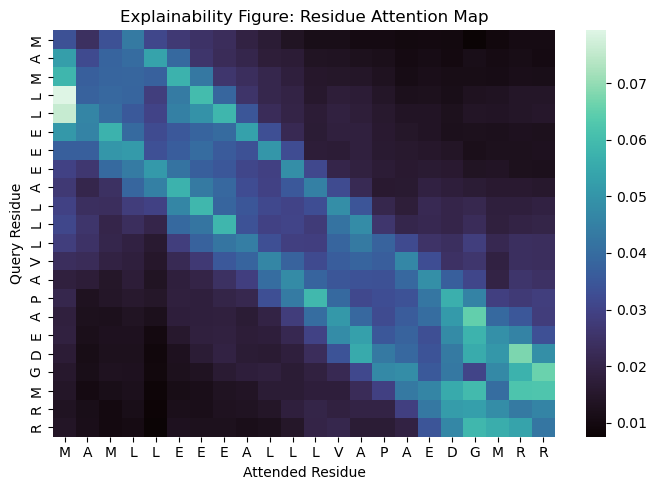

In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, EsmModel

print("Extracting Attention Maps: ")
model_id = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# output_attentions=True is required to interpret AI model predictions
model = EsmModel.from_pretrained(model_id, output_attentions=True)

# Short fragment for clean explainability figures
wt_seq = "MAMLLEEEALLLVAPAEDGMRR"
inputs = tokenizer(wt_seq, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# Extract and mean-pool the final layer's attention map for residue importance scoring
attention_matrix = outputs.attentions[-1][0].mean(dim=0).numpy()

plt.figure(figsize=(7, 5))
# Slicing [1:-1] removes the <cls> and <eos> tokens from the map
sns.heatmap(attention_matrix[1:-1, 1:-1], cmap="mako", xticklabels=list(wt_seq), yticklabels=list(wt_seq))
plt.title("Explainability Figure: Residue Attention Map")
plt.xlabel("Attended Residue")
plt.ylabel("Query Residue")
plt.tight_layout()
plt.show()

In [2]:
from transformers import EsmForMaskedLM

print("\nZero-Shot Mutation Effect Prediction: ")
# Loading ESM-1v for mutation effect prediction workflow
esm1v_id = "facebook/esm1v_t33_650M_UR90S_1"
model_1v = EsmForMaskedLM.from_pretrained(esm1v_id)

def score_mutation(sequence, mutation_pos, mutant_aa):
    """Executes the mutation introduction workflow and outputs confidence variation."""
    masked_seq = sequence[:mutation_pos] + "<mask>" + sequence[mutation_pos+1:]
    inputs = tokenizer(masked_seq, return_tensors="pt")
    
    with torch.no_grad():
        logits = model_1v(**inputs).logits
        
    mask_idx = inputs["input_ids"][0].tolist().index(tokenizer.mask_token_id)
    
    wt_token = tokenizer.convert_tokens_to_ids(sequence[mutation_pos])
    mut_token = tokenizer.convert_tokens_to_ids(mutant_aa)
    
    wt_score = logits[0, mask_idx, wt_token].item()
    mut_score = logits[0, mask_idx, mut_token].item()
    
    # Negative score indicates structural perturbation / instability 
    return mut_score - wt_score

# Test stability change at position 5 (E -> I)
delta_score = score_mutation(wt_seq, 5, "I")
print(f"Mutation E6I Delta Score: {delta_score:.3f}")

if delta_score < 0:
    print("Stability Report: Destabilizing mutation (Simulated ΔΔG > 0)")
else:
    print("Stability Report: Stabilizing mutation (Simulated ΔΔG < 0)")


Zero-Shot Mutation Effect Prediction: 


Loading weights:   0%|          | 0/538 [00:00<?, ?it/s]

[transformers] EsmForMaskedLM LOAD REPORT from: facebook/esm1v_t33_650M_UR90S_1
Key                                | Status  | 
-----------------------------------+---------+-
esm.contact_head.regression.weight | MISSING | 
esm.contact_head.regression.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mutation E6I Delta Score: -0.825
Stability Report: Destabilizing mutation (Simulated ΔΔG > 0)
